# Proyek Analisis Data: Klasifikasi Sampah Daur Ulang

## Menentukan Pertanyaan Bisnis

### Pertanyaan Bisnis (SMART)

1. Dalam snapshot `clean_sampah_metadata.csv` pada Tahap 1 (April 2026), berapa distribusi jumlah gambar per kategori, kategori mana yang memiliki porsi < 15% dari total data, dan berapa nilai imbalance ratio (kelas terbesar : kelas terkecil)?  
   Dampak bisnis: menetapkan prioritas augmentasi/penambahan data dan class weight sebelum training baseline.

2. Dalam snapshot yang sama (April 2026), kategori mana yang memiliki median ukuran file (KB) dan median resolusi (pixel) yang menyimpang >= 20% dari median keseluruhan, serta berapa outlier rate ukuran file (metode IQR) per kategori?  
   Dampak bisnis: menentukan standar preprocessing (resize, normalisasi, kompresi) dan quality check tambahan per kategori sebelum modeling.

## Import Semua Packages/Library yang Digunakan

In [1]:
import warnings
import os
import json
import getpass
import importlib.util
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

## Data Wrangling

### Gathering Data

#### Set Kredensial Kaggle
Isi `KAGGLE_USERNAME` dan `KAGGLE_KEY` Anda pada cell berikut (disarankan dari environment variable), atau simpan file `kaggle.json` di folder `~/.kaggle/`.

In [2]:
def setup_kaggle_credentials(prompt_if_missing=False, save_to_file=True):
    kaggle_json_path = Path.home() / ".kaggle" / "kaggle.json"
    username = os.getenv("KAGGLE_USERNAME", "")
    key = os.getenv("KAGGLE_KEY", "")

    # Prioritas 1: kredensial dari environment variable
    if username and key:
        source = "environment variable"
    # Prioritas 2: baca dari ~/.kaggle/kaggle.json jika ada
    elif kaggle_json_path.exists():
        with open(kaggle_json_path, "r", encoding="utf-8") as f:
            cfg = json.load(f)
        username = cfg.get("username", "")
        key = cfg.get("key", "")
        source = "~/.kaggle/kaggle.json"
    else:
        source = "belum ada"

    # Prioritas 3: input manual (opsional)
    if prompt_if_missing and (not username or not key):
        print("Masukkan kredensial Kaggle (API Token).")
        print("Bisa didapat dari: Kaggle > Account > Create New API Token")
        username = input("Kaggle Username: ").strip()
        key = getpass.getpass("Kaggle Key: ").strip()
        source = "input manual"

    if username and key:
        os.environ["KAGGLE_USERNAME"] = username
        os.environ["KAGGLE_KEY"] = key

        if save_to_file:
            kaggle_json_path.parent.mkdir(parents=True, exist_ok=True)
            with open(kaggle_json_path, "w", encoding="utf-8") as f:
                json.dump({"username": username, "key": key}, f)
            print(f"kaggle.json tersimpan di: {kaggle_json_path}")

        print(f"Kredensial Kaggle aktif (sumber: {source}).")
        return True

    print("Kredensial Kaggle belum tersedia. Download otomatis dari Kaggle mungkin gagal.")
    print("Set environment variable KAGGLE_USERNAME & KAGGLE_KEY jika ingin download otomatis.")
    return False

kaggle_ready = setup_kaggle_credentials(prompt_if_missing=False, save_to_file=True)
print("KAGGLE_USERNAME aktif:", bool(os.getenv("KAGGLE_USERNAME")))
print("KAGGLE_KEY aktif:", bool(os.getenv("KAGGLE_KEY")))

Kredensial Kaggle belum tersedia. Download otomatis dari Kaggle mungkin gagal.
Set environment variable KAGGLE_USERNAME & KAGGLE_KEY jika ingin download otomatis.
KAGGLE_USERNAME aktif: False
KAGGLE_KEY aktif: False


In [3]:
def ensure_package(package_name: str):
    if importlib.util.find_spec(package_name) is None:
        print(f"Menginstal package: {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name, "-q"])

def resolve_dataset_root(base_path: Path) -> Path | None:
    """Cari root folder dataset yang berisi subfolder kelas gambar."""
    if not base_path.exists() or not base_path.is_dir():
        return None

    image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    # Beberapa arsip membungkus data di folder DATASETS/dataset/data
    top_dirs = [d for d in base_path.iterdir() if d.is_dir()]
    if len(top_dirs) == 1 and top_dirs[0].name.lower() in {"datasets", "dataset", "data"}:
        candidate = top_dirs[0]
    else:
        candidate = base_path

    class_dirs = [d for d in candidate.iterdir() if d.is_dir()]
    if not class_dirs:
        return None

    has_images = False
    for class_dir in class_dirs:
        if any(p.suffix.lower() in image_exts for p in class_dir.rglob("*")):
            has_images = True
            break

    return candidate if has_images else None

# 1) Coba unduh dataset dari Kaggle secara otomatis (kagglehub).
# 2) Jika gagal, coba via Kaggle API resmi.
# 3) Jika tetap gagal, coba deteksi folder lokal secara otomatis.
DATASET_SLUG = "fathurrahmanalfarizy/sampah-daur-ulang"
AUTO_DOWNLOAD_DIR = Path("./data_kaggle")
FALLBACK_LOCAL_DIRS = [
    Path("./sampah-daur-ulang"),
    Path("./dataset"),
    Path("./data"),
]

dataset_path = None
download_error_messages = []

# Metode A: kagglehub
try:
    ensure_package("kagglehub")
    import kagglehub

    dataset_path = Path(kagglehub.dataset_download(DATASET_SLUG))
    print(f"Dataset berhasil diunduh via kagglehub ke: {dataset_path}")
except Exception as err:
    download_error_messages.append(f"kagglehub: {err}")

# Metode B: Kaggle API resmi
if dataset_path is None:
    try:
        ensure_package("kaggle")
        from kaggle.api.kaggle_api_extended import KaggleApi

        AUTO_DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
        api = KaggleApi()
        api.authenticate()
        api.dataset_download_files(DATASET_SLUG, path=str(AUTO_DOWNLOAD_DIR), unzip=True)
        dataset_path = AUTO_DOWNLOAD_DIR
        print(f"Dataset berhasil diunduh via Kaggle API ke: {dataset_path}")
    except Exception as err:
        download_error_messages.append(f"kaggle API: {err}")

# Metode C: auto-detect folder lokal
root_dir = None
if dataset_path is not None:
    root_dir = resolve_dataset_root(dataset_path)

if root_dir is None:
    for local_dir in FALLBACK_LOCAL_DIRS:
        detected = resolve_dataset_root(local_dir)
        if detected is not None:
            root_dir = detected
            print(f"Dataset ditemukan dari folder lokal: {root_dir.resolve()}")
            break

if root_dir is None:
    checked_dirs = "\n- ".join(str(p.resolve()) for p in FALLBACK_LOCAL_DIRS)
    error_text = "\n- ".join(download_error_messages) if download_error_messages else "(tidak ada detail error)"
    raise FileNotFoundError(
        "Dataset belum ditemukan.\n"
        "Silakan lakukan salah satu opsi berikut:\n"
        "1) Jalankan cell kredensial Kaggle dengan API token valid\n"
        "2) Ekstrak dataset manual ke salah satu folder berikut:\n"
        f"- {checked_dirs}\n\n"
        f"Detail error unduh otomatis:\n- {error_text}"
    )

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
records = []

class_dirs = [d for d in root_dir.iterdir() if d.is_dir()]
if not class_dirs:
    raise ValueError("Tidak ada folder kelas yang ditemukan pada dataset.")

for class_dir in class_dirs:
    for img_path in class_dir.rglob("*"):
        if img_path.suffix.lower() in image_exts:
            records.append(
                {
                    "file_path": str(img_path.resolve()),
                    "class_label": class_dir.name,
                    "file_name": img_path.name,
                    "file_ext": img_path.suffix.lower(),
                }
            )

raw_df = pd.DataFrame(records)

print(f"Jumlah baris metadata mentah: {len(raw_df):,}")
print(f"Jumlah kelas: {raw_df['class_label'].nunique()}")
raw_df.head()

Dataset berhasil diunduh via kagglehub ke: C:\Users\Lenovo\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5
Jumlah baris metadata mentah: 7,014
Jumlah kelas: 6


,file_path,class_label,file_name,file_ext
0,C:\Users\Lenovo\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3850.jpg,Kaca,R_3850.jpg,.jpg
1,C:\Users\Lenovo\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3851.jpg,Kaca,R_3851.jpg,.jpg
2,C:\Users\Lenovo\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3852.jpg,Kaca,R_3852.jpg,.jpg
3,C:\Users\Lenovo\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3853.jpg,Kaca,R_3853.jpg,.jpg
4,C:\Users\Lenovo\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3854.jpg,Kaca,R_3854.jpg,.jpg


**Insight:**
- Di tahap ini, data gambar sudah berhasil dibaca per kategori, jadi kita bisa lanjut hitung jumlah gambar di tiap kelas.
- Data ini juga sudah siap dipakai untuk melihat apakah ukuran dan dimensi gambar antar kategori berbeda atau tidak.

### Assessing Data

In [4]:
print("=== Struktur Data ===")
raw_df.info()

print("\n=== Missing Values ===")
print(raw_df.isna().sum())

print("\n=== Duplikasi ===")
print(f"Duplikasi file_path: {raw_df.duplicated(subset=['file_path']).sum()}")
print(f"Duplikasi file_name dalam kelas sama: {raw_df.duplicated(subset=['class_label', 'file_name']).sum()}")

print("\n=== Distribusi Kelas ===")
class_dist = (
    raw_df["class_label"]
    .value_counts()
    .rename_axis("class_label")
    .reset_index(name="n_images")
)
class_dist["pct"] = (class_dist["n_images"] / class_dist["n_images"].sum() * 100).round(2)
print(class_dist)

print("\n=== Distribusi Ekstensi File ===")
print(raw_df["file_ext"].value_counts())

=== Struktur Data ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7014 entries, 0 to 7013
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   file_path    7014 non-null   object
 1   class_label  7014 non-null   object
 2   file_name    7014 non-null   object
 3   file_ext     7014 non-null   object
dtypes: object(4)
memory usage: 219.3+ KB

=== Missing Values ===
file_path      0
class_label    0
file_name      0
file_ext       0
dtype: int64

=== Duplikasi ===
Duplikasi file_path: 0
Duplikasi file_name dalam kelas sama: 0

=== Distribusi Kelas ===
  class_label  n_images    pct
0      Kertas      1807  25.76
1     Plastik      1257  17.92
2       Logam      1210  17.25
3        Kaca      1110  15.83
4      Residu      1006  14.34
5      Kardus       624   8.90

=== Distribusi Ekstensi File ===
file_ext
.jpg    7014
Name: count, dtype: int64


**Insight:**
- Dari pengecekan awal, kelihatan kalau jumlah gambar tiap kategori belum seimbang.
- Informasi ini penting supaya kita tahu kelas mana yang terlalu banyak dan mana yang masih kurang datanya.

### Cleaning Data

In [ ]:
df = raw_df.copy()

# Standarisasi label kelas
df["class_label"] = df["class_label"].astype(str).str.strip().str.title()

# Hapus duplikasi berdasarkan nama file dan kelas (jika ada duplikat path, kita tidak menyimpan path ke output)
df = df.drop_duplicates(subset=["class_label", "file_name"])
df = df.dropna(subset=["class_label", "file_name", "file_ext"])

# Validasi file gambar sambil ekstrak metadata; kita tidak akan menyimpan field file_path ke CSV akhir
clean_records = []
corrupted_files = []

for row in df.itertuples(index=False):
    path = Path(row.file_path)
    try:
        if not path.exists():
            corrupted_files.append(str(row.file_path))
            continue

        file_size_kb = path.stat().st_size / 1024
        with Image.open(path) as img:
            img.verify()

        with Image.open(path) as img:
            width, height = img.size
            mode = img.mode

        clean_records.append(
            {
                "class_label": row.class_label,
                "file_name": row.file_name,
                "file_ext": row.file_ext,
                "width": width,
                "height": height,
                "aspect_ratio": round(width / height, 4) if height else np.nan,
                "pixels": width * height,
                "file_size_kb": round(file_size_kb, 2),
                "color_mode": mode,
            }
        )
    except Exception:
        corrupted_files.append(str(row.file_path))

clean_df = pd.DataFrame(clean_records)
clean_df = clean_df.dropna(subset=["width", "height", "aspect_ratio", "file_size_kb"])
clean_df = clean_df[(clean_df["width"] > 0) & (clean_df["height"] > 0)]

# Pastikan kolom path tidak tersimpan untuk privasi/kepraktisan
if "file_path" in clean_df.columns:
    clean_df = clean_df.drop(columns=["file_path"])

output_path = Path("clean_sampah_metadata.csv")
clean_df.to_csv(output_path, index=False)

print(f"Jumlah data setelah cleaning: {len(clean_df):,}")
print(f"File korup/tidak valid: {len(corrupted_files):,}")
print(f"Metadata bersih disimpan ke: {output_path.resolve()}")
clean_df.head()

Jumlah data setelah cleaning: 7,014
File korup/tidak valid: 0
Metadata bersih disimpan ke: C:\Users\Lenovo\OneDrive\Documents\Semester 6\Dicoding\Wranglingling\clean_sampah_metadata.csv


,file_path,class_label,file_name,file_ext,width,height,aspect_ratio,pixels,file_size_kb,color_mode
0,C:\Users\Lenovo\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3850.jpg,Kaca,R_3850.jpg,.jpg,225,225,1.0000,50625,2.60,RGB
1,C:\Users\Lenovo\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3851.jpg,Kaca,R_3851.jpg,.jpg,225,225,1.0000,50625,4.86,RGB
2,C:\Users\Lenovo\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3852.jpg,Kaca,R_3852.jpg,.jpg,225,225,1.0000,50625,2.65,RGB
3,C:\Users\Lenovo\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3853.jpg,Kaca,R_3853.jpg,.jpg,183,275,0.6655,50325,3.83,RGB
4,C:\Users\Lenovo\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3854.jpg,Kaca,R_3854.jpg,.jpg,194,259,0.7490,50246,3.16,RGB


In [ ]:
# Buat folder images dan simpan 1 gambar placeholder untuk setiap kategori (digunakan oleh Streamlit)
from PIL import Image, ImageDraw, ImageFont
images_dir = Path("images")
images_dir.mkdir(exist_ok=True)
categories = sorted(clean_df['class_label'].dropna().astype(str).unique().tolist())
created = 0
for cat in categories:
    slug = ''.join(c if c.isalnum() else '_' for c in cat.lower())
    img_path = images_dir / f"{slug}.png"
    if not img_path.exists():
        try:
            w, h = 640, 420
            img = Image.new('RGB', (w, h), color=(240, 240, 240))
            draw = ImageDraw.Draw(img)
            try:
                font = ImageFont.load_default()
            except Exception:
                font = None
            text = str(cat)
            if font is not None:
                tw, th = draw.textsize(text, font=font)
            else:
                tw, th = draw.textsize(text)
            draw.text(((w - tw) / 2, (h - th) / 2), text, fill=(30, 30, 30), font=font)
            img.save(img_path)
            created += 1
        except Exception:
            pass
print(f'Placeholder images created: {created} (folder: {images_dir.resolve()})')

**Insight:**
- Setelah cleaning, data jadi lebih rapi karena file duplikat, data kosong, dan gambar rusak sudah disaring.
- Sekarang perbandingan dimensi dan ukuran file antar kategori jadi lebih aman dan lebih bisa dipercaya.

## Exploratory Data Analysis (EDA)

### EDA Berbasis Pertanyaan SMART
Periode analisis: snapshot data bersih Tahap 1 (April 2026).

Sebelum visualisasi, agregasi dibuat terlebih dahulu untuk memastikan setiap pertanyaan memiliki indikator yang terukur:
- Q1 (kategorikal/univariate): distribusi kelas, persentase tiap kategori, dan imbalance ratio.
- Q2 (numerikal bivariate-multivariate): median ukuran file, median resolusi, deviasi terhadap median keseluruhan, serta outlier rate (IQR) per kategori.

Periode analisis: Snapshot clean_sampah_metadata.csv - Tahap 1 (April 2026)
Ukuran data bersih: (7014, 10)

Statistik univariat numerik:


,count,mean,std,min,25%,50%,75%,max
width,7014.0,288.384232,222.587257,42.0000,225.00,243.000,275.0000,6.270000e+03
height,7014.0,243.605503,190.454418,42.0000,183.00,220.000,225.0000,5.625000e+03
aspect_ratio,7014.0,1.242757,0.455802,0.2181,1.00,1.093,1.5027,6.465900e+00
pixels,7014.0,106892.276447,547708.913246,1764.0000,50325.00,50416.000,50625.0000,2.552517e+07
file_size_kb,7014.0,14.620194,64.374036,0.7700,4.04,6.375,10.3475,2.134540e+03



Agregasi Q1 - Distribusi kelas dan indikator ketidakseimbangan:


,class_label,n_images,pct,is_below_15pct
0,Kertas,1807,25.76,False
1,Plastik,1257,17.92,False
2,Logam,1210,17.25,False
3,Kaca,1110,15.83,False
4,Residu,1006,14.34,True
5,Kardus,624,8.90,True


Imbalance ratio (max:min) = 2.9x

Agregasi Q2 - Karakteristik gambar per kategori:


,class_label,n_images,median_width,median_height,median_file_size_kb,median_pixels,iqr_file_size_kb,outlier_rate_file_size_pct,delta_size_vs_overall_pct,delta_pixels_vs_overall_pct,needs_special_preprocessing
5,Residu,1006,287.0,253.0,8.06,50625.0,48.76,8.35,26.35,0.41,True
4,Plastik,1257,259.0,194.0,7.68,50400.0,6.17,4.22,20.47,-0.03,True
2,Kertas,1807,249.0,200.0,7.40,50400.0,8.09,0.39,16.08,-0.03,False
3,Logam,1210,237.0,206.0,6.18,50400.0,4.28,3.31,-2.98,-0.03,False
0,Kaca,1110,225.0,225.0,5.43,50401.0,3.52,2.43,-14.82,-0.03,False
1,Kardus,624,225.0,214.5,4.99,50437.0,2.74,4.65,-21.73,0.04,True


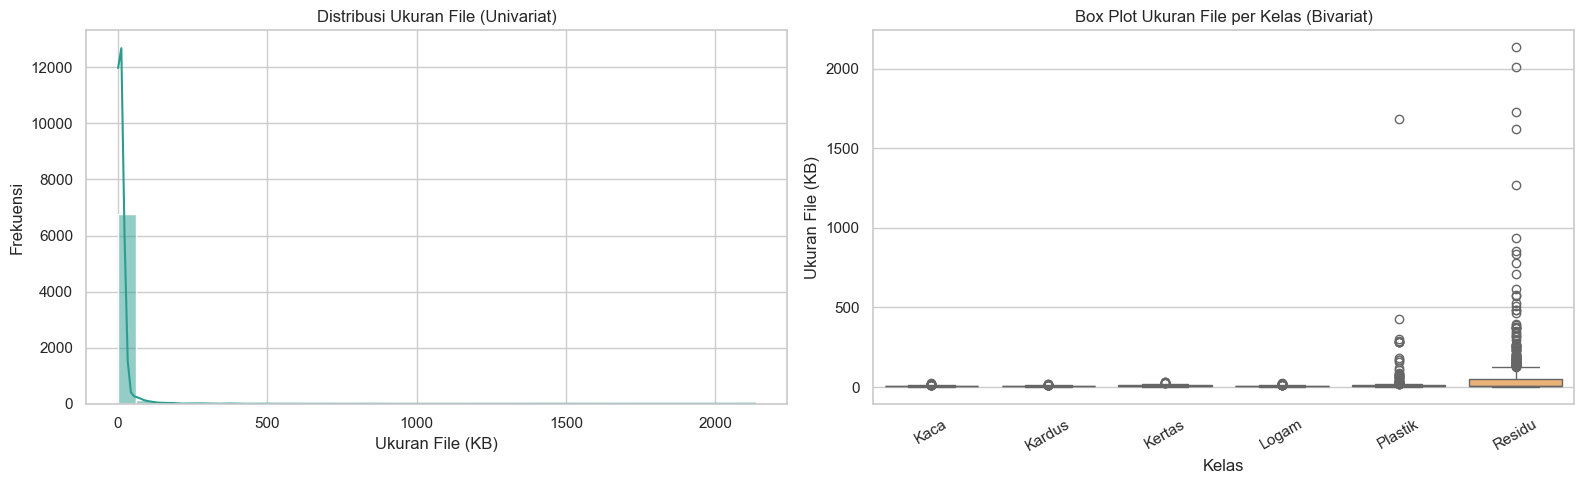

In [6]:
analysis_period = "Snapshot clean_sampah_metadata.csv - Tahap 1 (April 2026)"
numeric_cols = ["width", "height", "aspect_ratio", "pixels", "file_size_kb"]

print("Periode analisis:", analysis_period)
print("Ukuran data bersih:", clean_df.shape)

print("\nStatistik univariat numerik:")
display(clean_df[numeric_cols].describe().T)

# Agregasi untuk Pertanyaan SMART 1
q1_agg = (
    clean_df.groupby("class_label")
    .agg(n_images=("file_name", "count"))
    .sort_values("n_images", ascending=False)
    .reset_index()
)
q1_agg["pct"] = (q1_agg["n_images"] / q1_agg["n_images"].sum() * 100).round(2)
q1_agg["is_below_15pct"] = q1_agg["pct"] < 15

max_count = q1_agg["n_images"].max()
min_count = q1_agg["n_images"].min()
imbalance_ratio = round(max_count / min_count, 2)

print("\nAgregasi Q1 - Distribusi kelas dan indikator ketidakseimbangan:")
display(q1_agg)
print(f"Imbalance ratio (max:min) = {imbalance_ratio}x")

# Helper untuk menghitung outlier rate berbasis IQR
def iqr_outlier_rate(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).mean() * 100

overall_median_size = clean_df["file_size_kb"].median()
overall_median_pixels = clean_df["pixels"].median()

# Agregasi untuk Pertanyaan SMART 2
q2_agg = (
    clean_df.groupby("class_label")
    .agg(
        n_images=("file_name", "count"),
        median_width=("width", "median"),
        median_height=("height", "median"),
        median_file_size_kb=("file_size_kb", "median"),
        median_pixels=("pixels", "median"),
        iqr_file_size_kb=("file_size_kb", lambda s: s.quantile(0.75) - s.quantile(0.25)),
        outlier_rate_file_size_pct=("file_size_kb", iqr_outlier_rate),
    )
    .reset_index()
)

q2_agg["delta_size_vs_overall_pct"] = (
    (q2_agg["median_file_size_kb"] - overall_median_size) / overall_median_size * 100
).round(2)
q2_agg["delta_pixels_vs_overall_pct"] = (
    (q2_agg["median_pixels"] - overall_median_pixels) / overall_median_pixels * 100
).round(2)
q2_agg["needs_special_preprocessing"] = (
    q2_agg["delta_size_vs_overall_pct"].abs().ge(20)
    | q2_agg["delta_pixels_vs_overall_pct"].abs().ge(20)
    | q2_agg["outlier_rate_file_size_pct"].ge(5)
)

print("\nAgregasi Q2 - Karakteristik gambar per kategori:")
display(q2_agg.sort_values("median_file_size_kb", ascending=False).round(2))

# Visual pendukung EDA (sebelum explanatory analysis)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(clean_df["file_size_kb"], bins=35, kde=True, color="#2a9d8f", ax=axes[0])
axes[0].set_title("Distribusi Ukuran File (Univariat)")
axes[0].set_xlabel("Ukuran File (KB)")
axes[0].set_ylabel("Frekuensi")

sns.boxplot(data=clean_df, x="class_label", y="file_size_kb", palette="Set3", ax=axes[1])
axes[1].set_title("Box Plot Ukuran File per Kelas (Bivariat)")
axes[1].set_xlabel("Kelas")
axes[1].set_ylabel("Ukuran File (KB)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

**Insight EDA (SMART):**
- Q1 sudah terukur melalui `n_images`, `pct`, indikator `<15%`, dan `imbalance_ratio` untuk memetakan prioritas balancing data.
- Q2 sudah terukur melalui deviasi median ukuran file/resolusi terhadap median keseluruhan (`>=20%`) serta `outlier_rate_file_size_pct` per kategori.
- Dengan agregasi ini, tahap Visualization menjadi lebih terarah karena setiap grafik langsung menjawab indikator keputusan bisnis.

## Visualization & Explanatory Analysis

### Pertanyaan 1 (SMART): Dalam snapshot April 2026, bagaimana distribusi jumlah gambar per kategori, kategori mana dengan porsi <15%, dan berapa imbalance ratio?

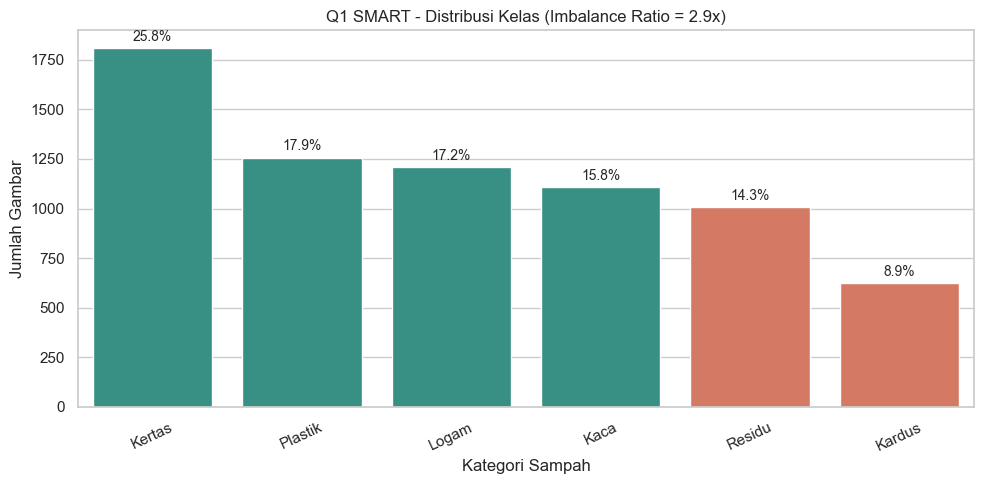

Ringkasan terukur Q1:
- Kelas mayoritas          : Kertas (1807 gambar)
- Kelas minoritas          : Kardus (624 gambar)
- Selisih mayoritas-minoritas: 1183 gambar
- Imbalance ratio (max:min): 2.9x
- Kategori dengan porsi <15%: ['Residu', 'Kardus']

Implikasi keputusan bisnis:
- Prioritaskan kategori dengan porsi <15% untuk augmentasi atau penambahan data.
- Gunakan class weight saat training baseline untuk menurunkan bias ke kelas mayoritas.


,class_label,n_images,pct,is_below_15pct
0,Kertas,1807,25.76,False
1,Plastik,1257,17.92,False
2,Logam,1210,17.25,False
3,Kaca,1110,15.83,False
4,Residu,1006,14.34,True
5,Kardus,624,8.90,True


In [7]:
# Gunakan agregasi dari tahap EDA jika sudah tersedia
if "q1_agg" in globals():
    q1_dist = q1_agg.copy()
else:
    q1_dist = (
        clean_df["class_label"]
        .value_counts()
        .rename_axis("class_label")
        .reset_index(name="n_images")
    )
    q1_dist["pct"] = (q1_dist["n_images"] / q1_dist["n_images"].sum() * 100).round(2)
    q1_dist["is_below_15pct"] = q1_dist["pct"] < 15

q1_dist = q1_dist.sort_values("n_images", ascending=False).reset_index(drop=True)

max_count = q1_dist["n_images"].max()
min_count = q1_dist["n_images"].min()
imbalance_ratio = round(max_count / min_count, 2)
majority_class = q1_dist.loc[q1_dist["n_images"].idxmax(), "class_label"]
minority_class = q1_dist.loc[q1_dist["n_images"].idxmin(), "class_label"]
count_gap = int(max_count - min_count)
under_15_classes = q1_dist.loc[q1_dist["is_below_15pct"], "class_label"].tolist()

plt.figure(figsize=(10, 5))
bar_colors = ["#e76f51" if x else "#2a9d8f" for x in q1_dist["is_below_15pct"]]
ax = sns.barplot(data=q1_dist, x="class_label", y="n_images", palette=bar_colors)

y_pad = max(1, int(max_count * 0.02))
for i, row in q1_dist.iterrows():
    ax.text(i, row["n_images"] + y_pad, f"{row['pct']:.1f}%", ha="center", fontsize=10)

plt.title(f"Q1 SMART - Distribusi Kelas (Imbalance Ratio = {imbalance_ratio}x)")
plt.xlabel("Kategori Sampah")
plt.ylabel("Jumlah Gambar")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

print("Ringkasan terukur Q1:")
print(f"- Kelas mayoritas          : {majority_class} ({max_count} gambar)")
print(f"- Kelas minoritas          : {minority_class} ({min_count} gambar)")
print(f"- Selisih mayoritas-minoritas: {count_gap} gambar")
print(f"- Imbalance ratio (max:min): {imbalance_ratio}x")
print(f"- Kategori dengan porsi <15%: {under_15_classes if under_15_classes else 'Tidak ada'}")

print("\nImplikasi keputusan bisnis:")
print("- Prioritaskan kategori dengan porsi <15% untuk augmentasi atau penambahan data.")
print("- Gunakan class weight saat training baseline untuk menurunkan bias ke kelas mayoritas.")

display(q1_dist[["class_label", "n_images", "pct", "is_below_15pct"]])

### Pertanyaan 2 (SMART): Dalam snapshot April 2026, kategori mana yang menyimpang >=20% dari median keseluruhan (ukuran file/resolusi) dan berapa outlier rate ukuran file per kategori?

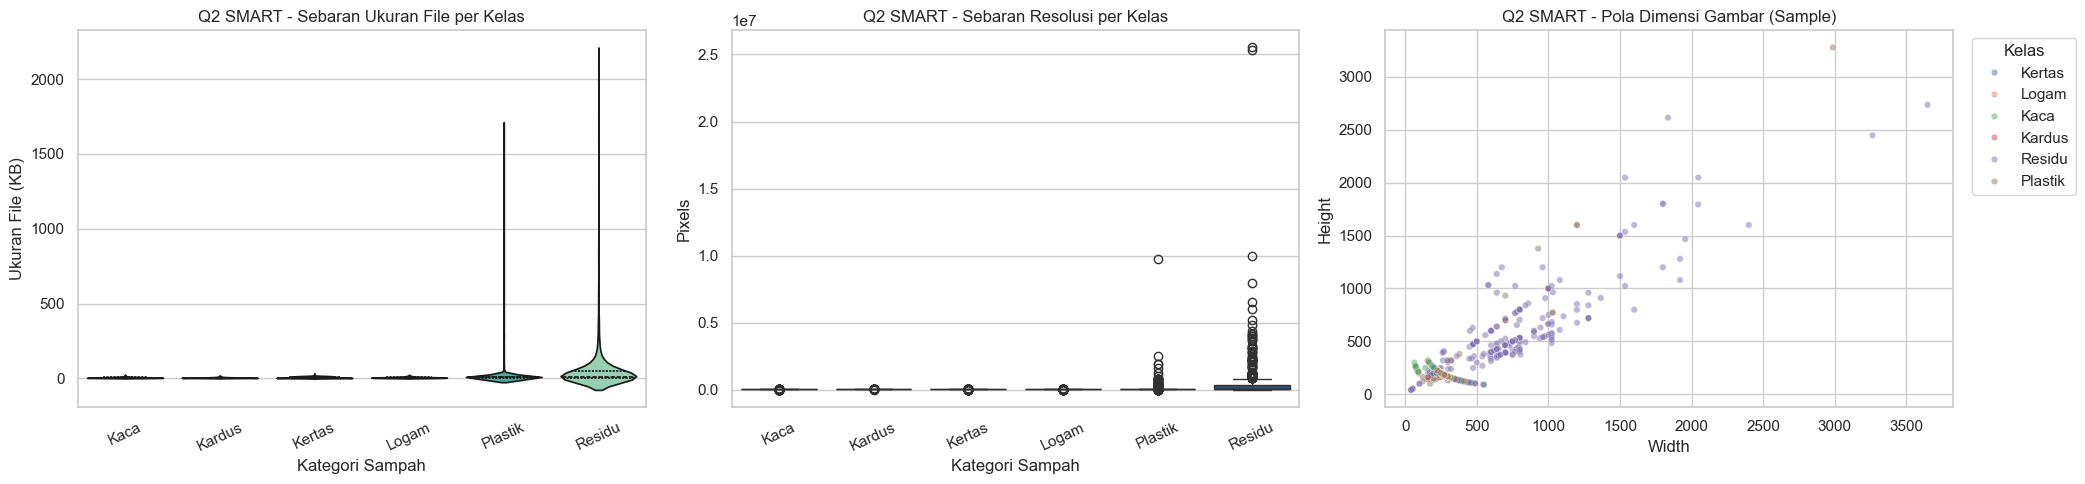

Ringkasan terukur Q2:
- Kategori prioritas preprocessing khusus (deviasi >=20% atau outlier rate >=5%):
  ['Residu', 'Plastik', 'Kardus']

Implikasi keputusan bisnis:
- Terapkan resize dan normalisasi konsisten sebagai baseline semua kategori.
- Beri quality check tambahan untuk kategori dengan outlier rate tinggi.
- Pertimbangkan strategi kompresi/standarisasi resolusi pada kategori yang deviasinya besar.


,class_label,n_images,median_file_size_kb,median_pixels,delta_size_vs_overall_pct,delta_pixels_vs_overall_pct,outlier_rate_file_size_pct,needs_special_preprocessing
0,Residu,1006,8.06,50625.0,26.35,0.41,8.35,True
1,Plastik,1257,7.68,50400.0,20.47,-0.03,4.22,True
2,Kertas,1807,7.40,50400.0,16.08,-0.03,0.39,False
3,Logam,1210,6.18,50400.0,-2.98,-0.03,3.31,False
4,Kaca,1110,5.43,50401.0,-14.82,-0.03,2.43,False
5,Kardus,624,4.99,50437.0,-21.73,0.04,4.65,True


In [8]:
# Gunakan agregasi dari tahap EDA jika sudah tersedia
if "q2_agg" in globals():
    q2_stats = q2_agg.copy()
else:
    def iqr_outlier_rate(series):
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:
            return 0.0
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        return ((series < lower) | (series > upper)).mean() * 100

    overall_median_size = clean_df["file_size_kb"].median()
    overall_median_pixels = clean_df["pixels"].median()

    q2_stats = (
        clean_df.groupby("class_label")
        .agg(
            n_images=("file_name", "count"),
            median_width=("width", "median"),
            median_height=("height", "median"),
            median_file_size_kb=("file_size_kb", "median"),
            median_pixels=("pixels", "median"),
            iqr_file_size_kb=("file_size_kb", lambda s: s.quantile(0.75) - s.quantile(0.25)),
            outlier_rate_file_size_pct=("file_size_kb", iqr_outlier_rate),
        )
        .reset_index()
)

    q2_stats["delta_size_vs_overall_pct"] = (
        (q2_stats["median_file_size_kb"] - overall_median_size) / overall_median_size * 100
).round(2)
    q2_stats["delta_pixels_vs_overall_pct"] = (
        (q2_stats["median_pixels"] - overall_median_pixels) / overall_median_pixels * 100
).round(2)
    q2_stats["needs_special_preprocessing"] = (
        q2_stats["delta_size_vs_overall_pct"].abs().ge(20)
        | q2_stats["delta_pixels_vs_overall_pct"].abs().ge(20)
        | q2_stats["outlier_rate_file_size_pct"].ge(5)
)

q2_stats = q2_stats.sort_values("median_file_size_kb", ascending=False).reset_index(drop=True)
priority_classes = q2_stats.loc[q2_stats["needs_special_preprocessing"], "class_label"].tolist()

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

sns.violinplot(
    data=clean_df, x="class_label", y="file_size_kb", inner="quartile", palette="mako", ax=axes[0]
)
axes[0].set_title("Q2 SMART - Sebaran Ukuran File per Kelas")
axes[0].set_xlabel("Kategori Sampah")
axes[0].set_ylabel("Ukuran File (KB)")
axes[0].tick_params(axis="x", rotation=25)

sns.boxplot(data=clean_df, x="class_label", y="pixels", palette="crest", ax=axes[1])
axes[1].set_title("Q2 SMART - Sebaran Resolusi per Kelas")
axes[1].set_xlabel("Kategori Sampah")
axes[1].set_ylabel("Pixels")
axes[1].tick_params(axis="x", rotation=25)

sampled_df = clean_df.sample(min(3000, len(clean_df)), random_state=42)
sns.scatterplot(
    data=sampled_df,
    x="width",
    y="height",
    hue="class_label",
    alpha=0.5,
    s=22,
    ax=axes[2],
)
axes[2].set_title("Q2 SMART - Pola Dimensi Gambar (Sample)")
axes[2].set_xlabel("Width")
axes[2].set_ylabel("Height")
axes[2].legend(title="Kelas", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

print("Ringkasan terukur Q2:")
print("- Kategori prioritas preprocessing khusus (deviasi >=20% atau outlier rate >=5%):")
print(f"  {priority_classes if priority_classes else 'Tidak ada'}")

print("\nImplikasi keputusan bisnis:")
print("- Terapkan resize dan normalisasi konsisten sebagai baseline semua kategori.")
print("- Beri quality check tambahan untuk kategori dengan outlier rate tinggi.")
print("- Pertimbangkan strategi kompresi/standarisasi resolusi pada kategori yang deviasinya besar.")

display(
    q2_stats[
        [
            "class_label",
            "n_images",
            "median_file_size_kb",
            "median_pixels",
            "delta_size_vs_overall_pct",
            "delta_pixels_vs_overall_pct",
            "outlier_rate_file_size_pct",
            "needs_special_preprocessing",
        ]
    ].round(2)
)

**Insight:**
- Pertanyaan 1 (SMART): distribusi kelas dapat diukur jelas melalui persentase dan imbalance ratio, sehingga kategori dengan porsi <15% dapat diprioritaskan untuk augmentasi.
- Pertanyaan 2 (SMART): deviasi median ukuran file/resolusi dan outlier rate per kategori menunjukkan kelas mana yang perlu preprocessing lebih ketat.
- Insight ini langsung dapat ditranslasikan ke keputusan pra-modeling: class weight, augmentasi terarah, resize-normalisasi konsisten, dan quality control tambahan.

## Analisis Lanjutan (Opsional)

In [9]:
# Analisis opsional: simulasi bobot kelas untuk menangani class imbalance pada tahap modeling
class_count = clean_df["class_label"].value_counts().sort_index()
class_weight = (class_count.sum() / (len(class_count) * class_count)).round(4)

class_weight_df = pd.DataFrame(
    {
        "class_label": class_weight.index,
        "n_images": class_count.values,
        "suggested_class_weight": class_weight.values,
    }
).sort_values("suggested_class_weight", ascending=False)

display(class_weight_df)

,class_label,n_images,suggested_class_weight
1,Kardus,624,1.8734
5,Residu,1006,1.1620
0,Kaca,1110,1.0532
3,Logam,1210,0.9661
4,Plastik,1257,0.9300
2,Kertas,1807,0.6469


## Conclusion

- Pada periode analisis snapshot Tahap 1 (April 2026), distribusi jumlah gambar per kategori menunjukkan ketidakseimbangan yang terukur melalui `imbalance_ratio` dan indikator porsi `<15%` untuk kelas prioritas.
- Pada periode yang sama, karakteristik ukuran file dan resolusi antar kategori menunjukkan deviasi yang dapat diukur (`>=20%` terhadap median keseluruhan) serta outlier rate berbasis IQR, sehingga preprocessing perlu dibedakan berdasarkan kategori.
- Keputusan bisnis yang actionable: prioritas augmentasi/penambahan data untuk kelas minoritas, penggunaan class weight saat training baseline, serta penerapan resize-normalisasi dan quality check tambahan pada kategori yang deviasinya tinggi.